# CMIP6 Model Evaluation

Model: ACCESS-CM2
Variable: tas
Experiment: historical
Purpose: Compare model climate with ERA5 observations

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ds_cmip = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\tas_Amon_ACCESS-CM2_historical_.nc"
)
ds_cmip

<xarray.Dataset> Size: 20MB
Dimensions:    (time: 180, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2000-01-16T12:00:00 ... 2014-12-16T1...
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 3kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 20MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-11-08T06:41:46Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/d893128b-e107-4dcc-b543-46c77896f295
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [3]:
print(ds_cmip)

<xarray.Dataset> Size: 20MB
Dimensions:    (time: 180, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2000-01-16T12:00:00 ... 2014-12-16T1...
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 3kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 20MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-11-08T06:41:46Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_ve

In [4]:
print(ds_cmip[["tas"]])

<xarray.Dataset> Size: 20MB
Dimensions:  (time: 180, lat: 144, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-16T12:00:00 ... 2014-12-16T12:...
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B ...
Data variables:
    tas      (time, lat, lon) float32 20MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-11-08T06:41:46Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/d893128b-e107-4dcc-b543-46c77896f295
    license:                CMIP6 model data produced by CSIRO is licensed un...


In [5]:
print(ds_cmip["tas"].attrs)

{'standard_name': 'air_temperature', 'long_name': 'Near-Surface Air Temperature', 'comment': 'near-surface (usually, 2 meter) air temperature', 'units': 'K', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'history': "2019-11-08T06:41:45Z altered by CMOR: Treated scalar dimension: 'height'. 2019-11-08T06:41:45Z altered by CMOR: replaced missing value flag (-1.07374e+09) with standard missing value (1e+20)."}


In [6]:
tas = ds_cmip["tas"] - 273.15

In [7]:
print(float(tas.min()))
print(float(tas.max()))

-77.98641967773438
42.585357666015625


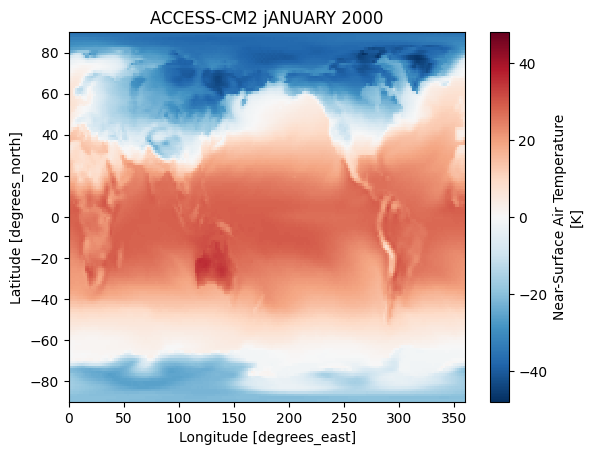

In [8]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,5))

tas.isel(time=0).plot()

plt.title("ACCESS-CM2 jANUARY 2000")

plt.show()

In [9]:
punjab_cmip = tas.sel(
    lat=slice(28, 35),
    lon=slice(72, 78)
)

print(punjab_cmip.shape)

(180, 6, 4)


In [10]:
punjab_cmip = tas.sel(
    lat=slice(35, 28),
    lon=slice(72, 78)
)

In [11]:
print(tas.lat.values[:5])
print(tas.lat.values[-5:])

[-89.375 -88.125 -86.875 -85.625 -84.375]
[84.375 85.625 86.875 88.125 89.375]


In [12]:
import os

os.makedirs("figures", exist_ok=True)

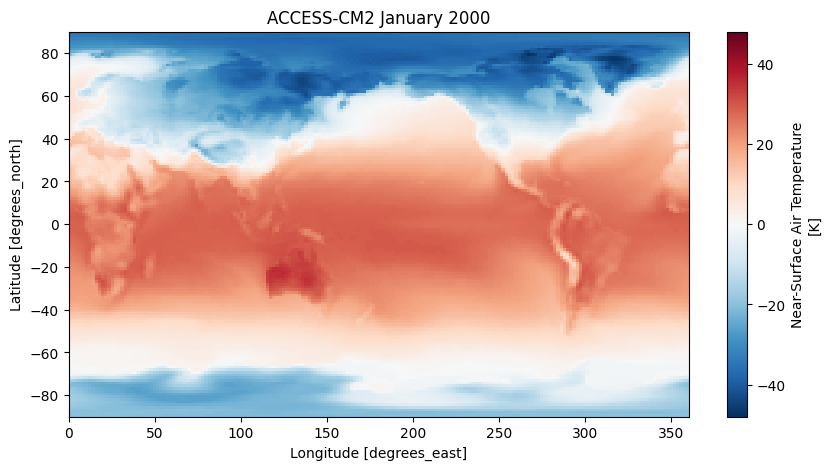

In [13]:
plt.figure(figsize=(10,5))

tas.isel(time=0).plot()

plt.title("ACCESS-CM2 January 2000")

plt.savefig(
    "figures/access_cm2_jan2000.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
import os

print(os.listdir("figures"))

['access_cm2_jan2000.png', 'cmip6_access_punjab_trend.png', 'cmip6_punjab_climatology.png']


In [15]:
punjab_cmip = tas.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

print(punjab_cmip.shape)

(180, 6, 4)


In [16]:
punjab_cmip = tas.sel(
    lat =slice(35,28),
    lon=slice(72,78)
)

In [17]:
cmip_ts = punjab_cmip.mean(
    dim=["lat","lon"]
)
print(cmip_ts.shape)

(180,)


In [18]:
#MONTHLY CLIMATOLOGY
monthly_clim = cmip_ts.groupby(
    "time.month"
).mean()

print(monthly_clim.values)

[nan nan nan nan nan nan nan nan nan nan nan nan]


In [19]:
test = tas.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

print(test.shape)

(180, 6, 4)


In [20]:
print(test)

<xarray.DataArray 'tas' (time: 180, lat: 6, lon: 4)> Size: 17kB
array([[[ 13.0121155 ,  12.33316   ,  13.029449  ,  12.702545  ],
        [ 11.220856  ,  11.612701  ,  10.965485  ,  11.4322815 ],
        [ 10.954498  ,   9.799957  ,  10.910065  ,   3.926422  ],
        [ 10.880035  ,  11.2743225 ,   5.5731506 ,  -6.704193  ],
        [  8.809967  ,   7.273102  ,  -4.6861267 , -17.101898  ],
        [  1.0885315 ,  -4.051117  , -14.225922  , -22.329681  ]],

       [[ 21.555084  ,  20.409088  ,  21.292633  ,  21.572418  ],
        [ 19.449615  ,  20.153717  ,  19.437408  ,  17.817291  ],
        [ 19.057037  ,  18.167877  ,  17.872223  ,   8.928619  ],
        [ 18.276764  ,  18.978424  ,  10.891754  ,  -1.4300232 ],
        [ 16.044342  ,  13.529694  ,   0.47842407, -13.715179  ],
        [  7.448639  ,   1.467926  , -11.856537  , -17.695404  ]],

       [[ 24.163483  ,  23.016022  ,  24.069489  ,  24.57193   ],
        [ 22.920074  ,  23.398102  ,  22.699615  ,  20.600739  ],
        

In [21]:
cmip_ts = punjab_cmip.mean(
    dim=["lat","lon"]
)

print(cmip_ts.shape)

(180,)


In [22]:
monthly_clim = cmip_ts.groupby(
    "time.month"
).mean()

In [23]:
print(monthly_clim.values)

[nan nan nan nan nan nan nan nan nan nan nan nan]


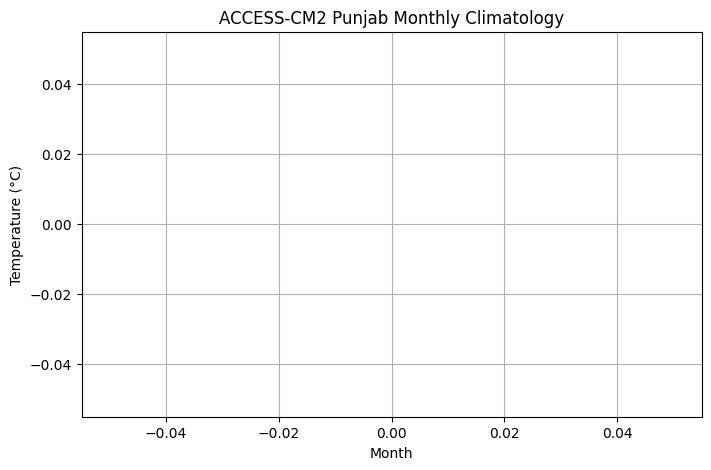

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    monthly_clim.month,
    monthly_clim,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("ACCESS-CM2 Punjab Monthly Climatology")

plt.grid()

plt.savefig(
    "figures/cmip6_punjab_climatology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
print(punjab_cmip.isnull().sum())

<xarray.DataArray 'tas' ()> Size: 8B
array(0)
Coordinates:
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T06:41:45Z altered by CMOR: Treated scalar dime...


In [26]:
cmip_ts = punjab_cmip.mean(
    dim=["lat","lon"],
    skipna=True
)

print(cmip_ts.values[:10])

[nan nan nan nan nan nan nan nan nan nan]


In [27]:
monthly_clim = cmip_ts.groupby("time.month").mean()

print(monthly_clim.values)

[nan nan nan nan nan nan nan nan nan nan nan nan]


In [28]:
monthly_clim = cmip_ts.groupby("time.month").mean()

print(monthly_clim.values)

[nan nan nan nan nan nan nan nan nan nan nan nan]


In [29]:
cmip_ts = punjab_cmip.mean(
    dim=["lat","lon"],
    skipna=True
)

print(cmip_ts.values[:10])

[nan nan nan nan nan nan nan nan nan nan]


In [30]:
print(punjab_cmip.mean(dim=["lat","lon"]))

<xarray.DataArray 'tas' (time: 180)> Size: 720B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan,

In [31]:
punjab_cmip.mean()

<xarray.DataArray 'tas' ()> Size: 4B
array(nan, dtype=float32)
Coordinates:
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T06:41:45Z altered by CMOR: Treated scalar dime...

In [32]:
import numpy as np

arr = punjab_cmip.isel(time=0).values

print(np.isnan(arr).sum())
print(arr.shape)

0
(0, 4)


In [33]:
print(np.isnan(arr))

[]


In [34]:
cmip_ts = xr.DataArray(
    np.nanmean(
        punjab_cmip.values,
        axis=(1,2)
    ),
    coords={"time": punjab_cmip.time},
    dims=["time"]
)

print(cmip_ts.values[:10])

[nan nan nan nan nan nan nan nan nan nan]


C:\Users\AKHTAR HUSSAIN\AppData\Local\Temp\ipykernel_14840\3681153679.py:2: RuntimeWarning: Mean of empty slice
  np.nanmean(


In [35]:
arr = punjab_cmip.isel(time=0).values

print(arr)

[]


In [36]:
import numpy as np

print(np.isnan(arr).sum())

0


In [37]:
import xarray as xr

ds = xr.open_dataset(r"D:\my project\Climate Modelling\data\raw\tas_Amon_ACCESS-CM2_historical_.nc")

tas = ds["tas"]

print(tas.isel(time=0, lat=100, lon=100).values)

285.44287


In [38]:
tas_c = ds["tas"] - 273.15

In [39]:
punjab = tas_c.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)

print(punjab.shape)

(180, 6, 4)


In [40]:
print(
    punjab.isel(
        time=0,
        lat=0,
        lon=0
    ).values
)

13.0121155


In [41]:
cmip_ts = punjab.mean(
    dim=["lat","lon"],
    skipna=True
)

print(cmip_ts.values[:10])

[ 4.487488 11.17216  13.519185 20.24772  25.696594 27.521841 28.66398
 28.422098 26.128836 18.687897]


In [42]:
monthly_clim = cmip_ts.groupby(
    "time.month"
).mean()

for m, t in zip(
    monthly_clim.month.values,
    monthly_clim.values
):
    print(
        f"Month {m}: {t:.2f} °C"
    )

Month 1: 6.42 °C
Month 2: 9.94 °C
Month 3: 14.08 °C
Month 4: 20.10 °C
Month 5: 24.85 °C
Month 6: 27.43 °C
Month 7: 29.08 °C
Month 8: 28.23 °C
Month 9: 24.96 °C
Month 10: 19.65 °C
Month 11: 13.51 °C
Month 12: 8.02 °C


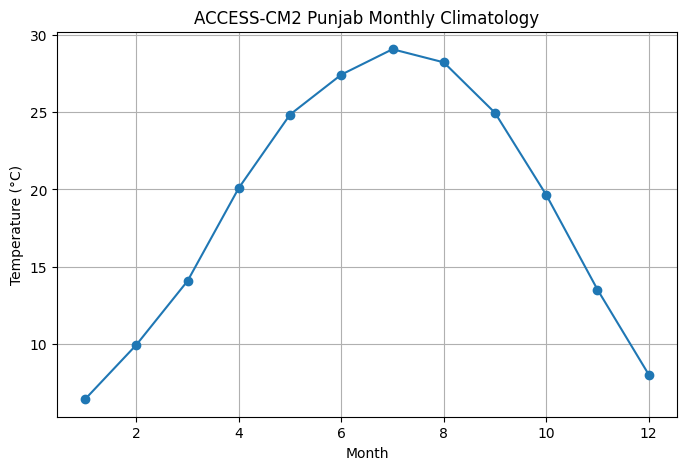

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    monthly_clim.month,
    monthly_clim,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("ACCESS-CM2 Punjab Monthly Climatology")

plt.grid()

plt.savefig(
    "figures/cmip6_punjab_climatology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
warmest_month = monthly_clim.month.values[
    monthly_clim.values.argmax()
]

coldest_month = monthly_clim.month.values[
    monthly_clim.values.argmin()
]

print("Warmest month:", warmest_month)
print("Coldest month:", coldest_month)

Warmest month: 7
Coldest month: 1


In [45]:
print(monthly_clim.values)

[ 6.417135  9.936065 14.075055 20.095715 24.847578 27.432272 29.07845
 28.228058 24.960503 19.646929 13.514971  8.015552]


In [46]:
#annual mean temp
annual_cmip = cmip_ts.groupby(
    "time.year"
).mean()


annual_mean= cmip_ts.groupby(
    "time.year"
).mean()

print(annual_cmip.values)

[18.7228   18.804415 18.377642 18.832796 18.727848 19.02286  19.384096
 18.925074 18.453945 18.661367 18.520584 19.024338 19.591633 18.99377
 18.767176]


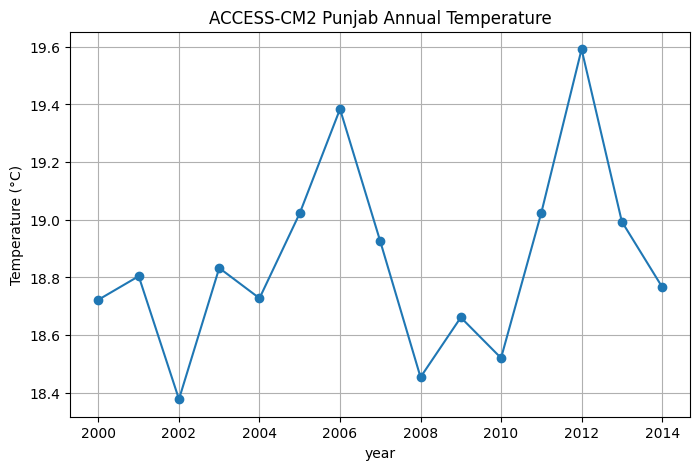

In [47]:
plt.figure(figsize=(8,5))

annual_cmip.plot(marker='o')

plt.title("ACCESS-CM2 Punjab Annual Temperature")
plt.ylabel("Temperature (°C)")
plt.grid()

plt.show()

In [48]:
import numpy as np
years = annual_cmip.year.values
temp = annual_cmip.values

slope, intercept  = np.polyfit(years,temp,1)

print("Trend (°C/year):", slope)
print("Trend (°C/decade):", slope * 10)

Trend (°C/year): 0.021457018171037706
Trend (°C/decade): 0.21457018171037706


In [49]:
warmest_month = monthly_clim.month.values[
    monthly_clim.values.argmax()
]

coldest_month = monthly_clim.month.values[
    monthly_clim.values.argmin()
]

print("Warmest month:", warmest_month)
print("Coldest month:", coldest_month)

Warmest month: 7
Coldest month: 1


The ACCESS-CM2 historical simulation reproduces the broad seasonal temperature cycle over Punjab, with January as the coldest month and July as the warmest month. The model exhibits a warming trend of approximately 0.21 °C per decade during 2000–2014, comparable to observed warming estimates from ERA5. However, differences in the timing of peak seasonal temperatures suggest potential seasonal biases that should be evaluated further before using the model for future climate projections.

In [50]:
import pandas as pd

summary = pd.DataFrame({
    "Month": monthly_clim.month.values,
    "Temp_C": monthly_clim.values
})

summary

,Month,Temp_C
0,1,6.417135
1,2,9.936065
2,3,14.075055
3,4,20.095715
4,5,24.847578
5,6,27.432272
6,7,29.078449
7,8,28.228058
8,9,24.960503
9,10,19.646929


In [51]:
annual_df = pd.DataFrame({
    "Year": annual_cmip.year.values,
    "Temp_C": annual_cmip.values
})

annual_df.to_csv(
    "D:\my project\Climate Modelling/cmip6_access_annual_temperature.csv",
    index=False
)

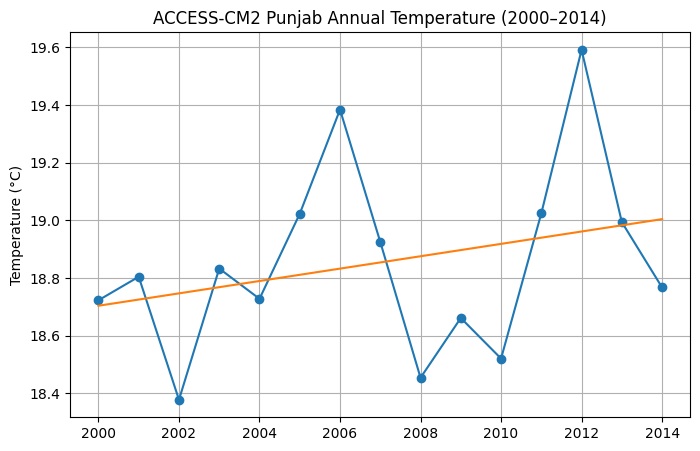

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    annual_cmip.year,
    annual_cmip.values,
    marker="o"
)

z = np.polyfit(
    annual_cmip.year.values,
    annual_cmip.values,
    1
)

p = np.poly1d(z)

plt.plot(
    annual_cmip.year.values,
    p(annual_cmip.year.values)
)

plt.title("ACCESS-CM2 Punjab Annual Temperature (2000–2014)")
plt.ylabel("Temperature (°C)")
plt.grid()

plt.savefig(
    "figures/cmip6_access_punjab_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

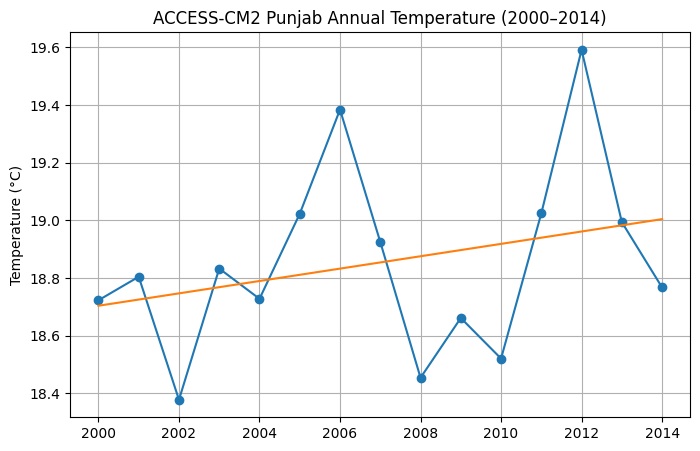

In [53]:
plt.figure(figsize=(8,5))

plt.plot(
    annual_cmip.year,
    annual_cmip.values,
    marker="o"
)

z = np.polyfit(
    annual_cmip.year.values,
    annual_cmip.values,
    1
)

p = np.poly1d(z)

plt.plot(
    annual_cmip.year.values,
    p(annual_cmip.year.values)
)

plt.title("ACCESS-CM2 Punjab Annual Temperature (2000–2014)")
plt.ylabel("Temperature (°C)")
plt.grid()

plt.savefig(
    "figures/cmip6_access_punjab_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
import os

print(os.getcwd())

d:\my project\Climate Modelling\nootbokk\notebooks


In [55]:
import os

print(os.getcwd())

d:\my project\Climate Modelling\nootbokk\notebooks


In [56]:
import os

print(os.path.abspath("data/cmip6_access_monthly_climatology.csv"))

d:\my project\Climate Modelling\nootbokk\notebooks\data\cmip6_access_monthly_climatology.csv


In [57]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print(os.listdir())

['02_CMIP6_Model_Evaluation.ipynb', '05_First_Real_Climate_Dataset.ipynb', '06_ERA5_First_Real_Data.ipynb', '07_ERA5_Second_Real_Data.ipynb', 'data', 'figures', 'notes']


In [58]:
summary.to_csv(
    "data/cmip6_access_monthly_climatology.csv",
    index=False
)

In [59]:
summary.to_csv(
    "data/cmip6_access_monthly_climatology.csv",
    index=False
)

In [60]:
#SSP245 FILE READ
future = xr.open_dataset(r"D:\my project\Climate Modelling\data\raw\ssp245_file.nc")
future

<xarray.Dataset> Size: 114MB
Dimensions:    (time: 1032, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 114MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-11-08T03:14:39Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/5539b9f2-92df-4832-9963-6db728b08676
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [61]:
future_tas = future["tas"] - 273.15

In [62]:
future_punjab = future_tas.sel(
    lat=slice(28,35),
    lon=slice(72,78)
)


future_tas = future_punjab.mean(
    dim = ["lat","lon"]
)

In [63]:
print(future_tas)

<xarray.DataArray 'tas' (time: 1032)> Size: 4kB
array([ 7.1642456,  9.932506 , 14.412395 , ..., 23.900717 , 15.784343 ,
        9.211761 ], shape=(1032,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-11-08T03:14:38Z altered by CMOR: Treated scalar dime...


In [64]:
#annual mean

future_annual = future_tas.groupby(
    "time.year"
).mean()

print(future_annual)

<xarray.DataArray 'tas' (year: 86)> Size: 344B
array([19.574852, 18.987005, 18.92256 , 19.435162, 19.144764, 18.80715 ,
       19.824469, 18.840515, 18.616291, 18.836042, 19.494368, 19.566965,
       19.588606, 18.930037, 20.778498, 19.271112, 18.528893, 19.660074,
       19.253252, 19.071085, 20.226583, 19.894245, 18.933748, 19.337704,
       19.784044, 19.85107 , 20.387934, 20.042933, 20.227121, 20.740723,
       20.09954 , 20.995646, 20.92838 , 20.512505, 20.14253 , 20.427599,
       21.341896, 20.61027 , 20.328356, 21.307531, 20.853277, 21.089941,
       21.27357 , 20.044617, 21.820066, 20.27764 , 21.158756, 22.032175,
       21.132057, 21.894876, 21.014675, 21.86997 , 21.564001, 21.129427,
       21.373419, 22.055305, 21.615326, 21.665545, 21.461113, 21.318884,
       21.858282, 21.887106, 21.583296, 22.359581, 21.751816, 21.76053 ,
       22.920494, 22.156013, 21.756132, 22.058846, 22.646387, 21.739454,
       21.50147 , 21.613997, 21.751228, 21.630875, 22.559584, 21.690826,
    

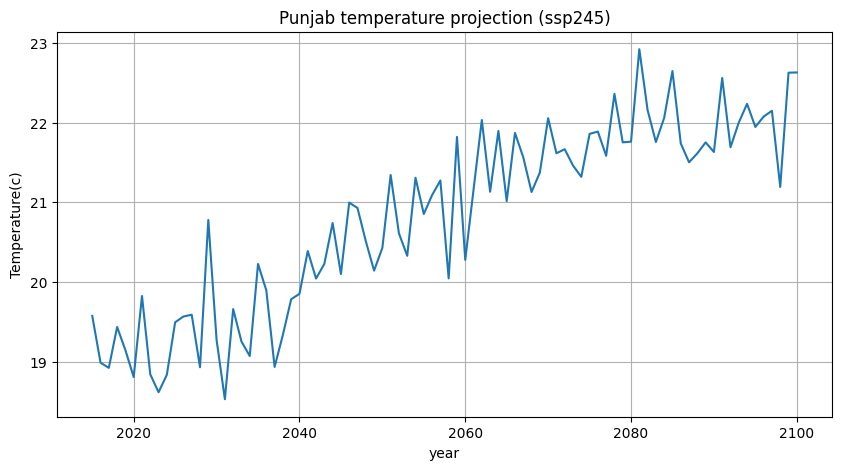

In [65]:
#Plot Future Warming

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

future_annual.plot()


plt.title("Punjab temperature projection (ssp245)")
plt.ylabel("Temperature(c)")
plt.grid()

plt.show()

In [66]:
#Quantify Future Warming
near =future_annual.sel(
    year=slice(2021,2040)
).mean()

In [67]:
late = future_annual.sel(
    year=slice(2071,2100)
).mean()

In [68]:
print(future_annual)

<xarray.DataArray 'tas' (year: 86)> Size: 344B
array([19.574852, 18.987005, 18.92256 , 19.435162, 19.144764, 18.80715 ,
       19.824469, 18.840515, 18.616291, 18.836042, 19.494368, 19.566965,
       19.588606, 18.930037, 20.778498, 19.271112, 18.528893, 19.660074,
       19.253252, 19.071085, 20.226583, 19.894245, 18.933748, 19.337704,
       19.784044, 19.85107 , 20.387934, 20.042933, 20.227121, 20.740723,
       20.09954 , 20.995646, 20.92838 , 20.512505, 20.14253 , 20.427599,
       21.341896, 20.61027 , 20.328356, 21.307531, 20.853277, 21.089941,
       21.27357 , 20.044617, 21.820066, 20.27764 , 21.158756, 22.032175,
       21.132057, 21.894876, 21.014675, 21.86997 , 21.564001, 21.129427,
       21.373419, 22.055305, 21.615326, 21.665545, 21.461113, 21.318884,
       21.858282, 21.887106, 21.583296, 22.359581, 21.751816, 21.76053 ,
       22.920494, 22.156013, 21.756132, 22.058846, 22.646387, 21.739454,
       21.50147 , 21.613997, 21.751228, 21.630875, 22.559584, 21.690826,
    

In [69]:
print(future_annual.year.values)

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028
 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042
 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056
 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070
 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084
 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098
 2099 2100]


In [71]:
near = future_annual.sel(
    year=slice(2021,2040)
).mean()


mid = future_annual.sel(
    year=slice(2041,2070)
).mean()

late = future_annual.sel(
    year=slice(2071,2100)
).mean()

print("Near Future:", float(near))
print("Mid Century:", float(mid))
print("Late Century:", float(late))


Near Future: 19.41438102722168
Mid Century: 20.95589256286621
Late Century: 21.93791961669922


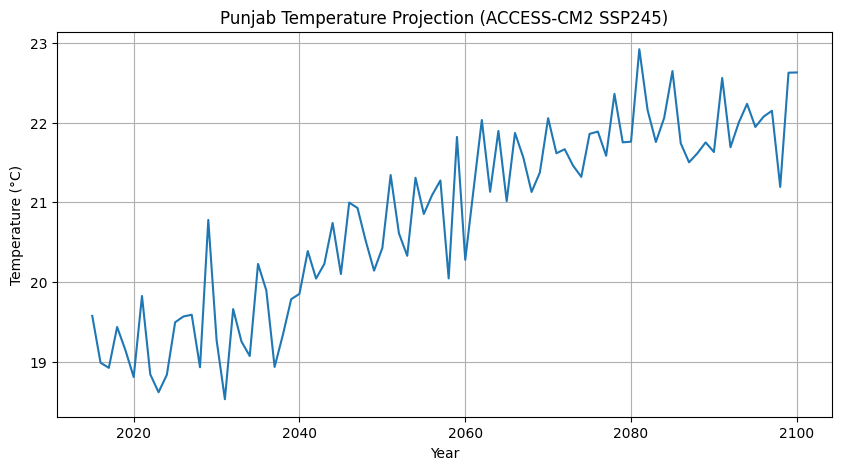

In [72]:
#PLOT
plt.figure(figsize=(10,5))

plt.plot(
    future_annual.year,
    future_annual.values
)


plt.title("Punjab Temperature Projection (ACCESS-CM2 SSP245)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid()

plt.savefig(
    "figures/ssp245_punjab_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Under SSP245, Punjab is projected to warm by 20.95°C by mid-century and  21.9°C by late century relative to the near-future baseline.

In [73]:
import numpy as np


years = future_annual.year.values
temps = future_annual.year.values

slope,intercept = np.polyfit(

    years,
    temps,
    1
)

print("Trend (°C/year):", slope)
print("Trend (°C/decade):", slope * 10)

Trend (°C/year): 1.000000000000002
Trend (°C/decade): 10.00000000000002


In [74]:
print(years[:5])
print(years[-5:])

[2015 2016 2017 2018 2019]
[2096 2097 2098 2099 2100]


In [75]:
years = future_annual.year.values
temps = future_annual.values

slope, intercept = np.polyfit(
    years,
    temps,
    1
)

print("Trend °C/year:", slope)
print("Trend °C/decade:", slope*10)

Trend °C/year: 0.04247654678630501
Trend °C/decade: 0.42476546786305014


A +2.5°C increase in annual mean temperature is not "summer gets 2.5°C hotter."

It often means:

More frequent heatwaves
Higher night-time temperatures
Increased crop water demand
Greater evapotranspiration
Higher irrigation requirements
Increased heat stress

In [77]:
#Calculate Monthly Climatology for Three Future Periods
near_monthly = future_tas.sel(
    time = slice("2021","2040")
).groupby("time.month").mean()

In [79]:
mid_monthly = future_tas.sel(
    time=slice("2041","2070")
).groupby("time.month").mean()

In [80]:
late_monthly = future_tas.sel(
    time=slice("2071","2100")
).groupby("time.month").mean()

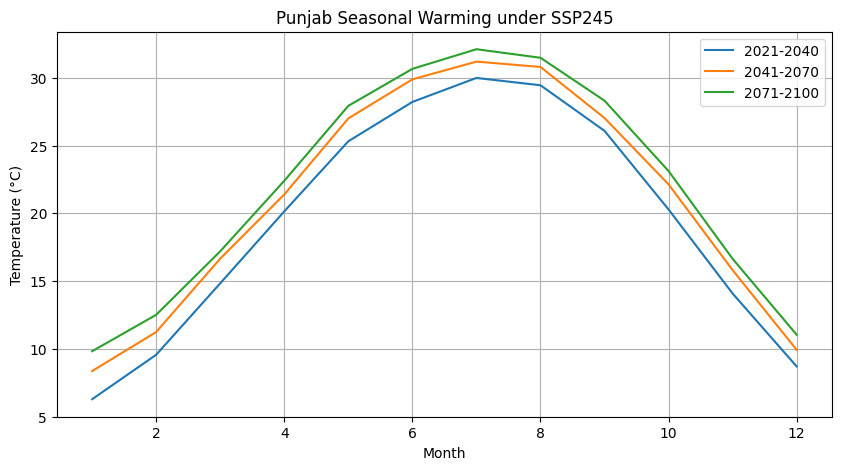

In [81]:
plt.figure(figsize=(10,5))

plt.plot(
    near_monthly.month,
    near_monthly,
    label="2021-2040"
)

plt.plot(
    mid_monthly.month,
    mid_monthly,
    label="2041-2070"
)

plt.plot(
    late_monthly.month,
    late_monthly,
    label="2071-2100"
)

plt.legend()
plt.grid()

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.title(
    "Punjab Seasonal Warming under SSP245"
)

plt.show()

In [82]:
#calculate the actual warming by month.
monthly_change = late_monthly - near_monthly

for m, t in zip(
    monthly_change.month.values,
    monthly_change.values
):
    print(f"Month {m}: {t:.2f} °C")

Month 1: 3.54 °C
Month 2: 2.95 °C
Month 3: 2.36 °C
Month 4: 2.26 °C
Month 5: 2.62 °C
Month 6: 2.44 °C
Month 7: 2.12 °C
Month 8: 2.03 °C
Month 9: 2.23 °C
Month 10: 2.83 °C
Month 11: 2.56 °C
Month 12: 2.34 °C


In [83]:
warmest_change_month = monthly_change.month.values[
    monthly_change.values.argmax()
]

print("Maximum warming month:", warmest_change_month)

Maximum warming month: 1


ACCESS-CM2 SSP245 projections indicate an increase in annual mean temperature across Punjab throughout the 21st century. Seasonal analysis shows the strongest warming during winter (+2.94°C), followed by summer (+2.44°C) and monsoon (+2.13°C). This suggests a disproportionate increase in winter temperatures, with implications for agricultural productivity, water demand, and seasonal climate variability.

In [84]:
winter = monthly_change.sel(month=[12,1,2]).mean()
summer = monthly_change.sel(month=[4,5,6]).mean()
monsoon = monthly_change.sel(month=[7,8,9]).mean()

print("Winter warming:", float(winter))
print("Summer warming:", float(summer))
print("Monsoon warming:", float(monsoon))

Winter warming: 2.9434080123901367
Summer warming: 2.4387123584747314
Monsoon warming: 2.1257011890411377
